# Programming Assignment 3 - Scalable Clustering Techniques

In [22]:
# imports for the whole homework
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows with MKL")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from collections import defaultdict

from sklearn.cluster import KMeans
import datetime

In [2]:
def load_covertype(file_path=r"./datasets/covtype.data.gz"):
    """
    Loads the Covertype dataset from a gzipped CSV file.
    Default path is relative to the current directory.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found at {file_path}. Please check the directory path.")

    print("Loading Covertype dataset")
    
    df = pd.read_csv(file_path, header=None, compression='gzip')
    
    X = df.iloc[:, :-1].values.astype(np.float32)
    
    y = df.iloc[:, -1].values.astype(np.int32)
    
    print(f"Dataset Loaded Successfully.")
    print(f"Instances: {X.shape[0]}, Features: {X.shape[1]}, Classes: {len(np.unique(y))}")
    
    return X, y

## 1. Lloyd’s algorithm for k-Means Clustering

Task:

As a baseline model implement
Lloyd’s algorithm [4] for k-means clustering and initialize it with the first k points as
initial cluster centers. The default convergence criteria is to stop the algorithm if none
of the cluster memberships have changed in comparison to the previous iteration.

✓ Include a plot illustrating convergence of k-means.

✓ Track the number of iterations needed for convergence and compare it to the other
implementations.

✓ Report the achieved NMI averaged over at least 5 runs.

✓ Report the runtime in [sec] for your algorithm averaged over at least 5 runs. Also
report the number of distance computations performed.

✓ Briefly discuss your implementation of Lloyd's algorithm.

-----

* Our implementation of Lloyd's algorithm is based on slide 9 from the Unsupervised handout. 

It starts by initializing cluster centers using the first k points of the dataset after applying a standard scaler. In each iteration, it alternates between assigning points to their nearest center and updating those centers to the mean of their assigned samples. The process repeats until cluster memberships no longer change, as the algorithm has reached a stable local minimum.

One issue we encountered was an error of not enough memory to allocate a matrix of almost 4Gb. Because of this, we did not use directly the literal computation (which can be seen in line 21), but made a more optimized one (lines 24-26). The number of iterations and the number of distance computations are exactly the same, but the program does not crash anymore.

In [11]:
def lloyds_algorithm(X, k, y_true, max_iter=100):
    """
    Implementation of Lloyd's algorithm as seen in slide 9 of Unsupervised handout.
    """
    # initialization
    mu = X[:k, :].copy()
    
    n_samples = X.shape[0]
    z = np.zeros(n_samples, dtype=int) # cluster memberships
    history_sq_dist = []

    total_dist_comps = 0
    
    start_time = time.time()

    for t in range(1, max_iter + 1):
        total_dist_comps += (n_samples * k)
        # cluster assignments (z_i^(t))
        # this is the literal computation
        # distances_sq = np.sum((X[:, np.newaxis, :] - mu)**2, axis=2)

        # optimized calculation for large datasets, because the line from uses a lot of memory
        x_sq = np.sum(X**2, axis=1, keepdims=True)
        mu_sq = np.sum(mu**2, axis=1)
        distances_sq = x_sq + mu_sq - 2 * np.dot(X, mu.T)
        
        new_z = np.argmin(distances_sq, axis=1)
        
        # track the sum of squared distances for the convergence plot
        inertia = np.sum(np.min(distances_sq, axis=1))
        history_sq_dist.append(inertia)

        # convergence criteria - stop if none of the cluster memberships (z) have changed
        if np.array_equal(new_z, z):
            print(f"Converged at iteration {t}")
            break
        z = new_z.copy()

        # update cluster centers
        for j in range(k):
            assigned_points = X[z == j]
            if len(assigned_points) > 0:
                mu[j] = np.mean(assigned_points, axis=0)

    runtime = time.time() - start_time
    
    nmi = normalized_mutual_info_score(y_true, z, average_method='arithmetic')
    
    return nmi, t, history_sq_dist, runtime, total_dist_comps

In [5]:
def run_experiment(X_raw, y_raw, k_values=[7, 30], num_runs=5, output_file="clustering_results.txt"):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    final_report = {}

    with open(output_file, "a") as f:
        f.write("\n" + "="*60 + "\n")
        f.write(f"NEW EXPERIMENT RUN: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("Method: Lloyd's Algorithm (Baseline)\n")
        f.write("="*60 + "\n")

        for k in k_values:
            run_nmis = []
            run_iters = []
            run_times = []
            run_dist_comps = []
            
            print(f"\nEvaluating Lloyd's Algorithm for k={k}...")
            
            for r in range(num_runs):
                # shuffle data so first k points vary between runs for averaging
                X_s, y_s = shuffle(X_scaled, y_raw, random_state=r)
                
                nmi, iters, history, duration, dist_comps = lloyds_algorithm(X_s, k, y_s)
                
                run_nmis.append(nmi)
                run_iters.append(iters)
                run_times.append(duration)
                run_dist_comps.append(dist_comps)
                
                if r == num_runs-1:
                    plt.figure(figsize=(7, 4))
                    plt.plot(range(1, len(history) + 1), history, marker='x', color='tab:orange')
                    plt.title(f"Lloyd's Convergence (k={k}, Run {r+1})")
                    plt.xlabel("Iteration (t)")
                    plt.ylabel("Total Squared Distance")
                    plt.grid(True)
                    plt.show()
            
            report_str = (f"k={k} Average Results ({num_runs} runs):\n"
                        f" - NMI: {np.mean(run_nmis):.4f}\n"
                        f" - Iterations: {np.mean(run_iters):.1f}\n"
                        f" - Runtime: {np.mean(run_times):.2f}s\n"
                        f" - Distance Computations: {np.mean(run_dist_comps):,.0f}\n")
            print(report_str)
            f.write(report_str + "-"*30 + "\n")

            final_report[k] = {"nmi": np.mean(run_nmis), "iters": np.mean(run_iters), "runtime": np.mean(run_times), "dist_comps": np.mean(run_dist_comps)}
        
    return final_report

Loading Covertype dataset
Dataset Loaded Successfully.
Instances: 581012, Features: 54, Classes: 7

Evaluating Lloyd's Algorithm for k=7...
Converged at iteration 19
Converged at iteration 22
Converged at iteration 24
Converged at iteration 35
Converged at iteration 32


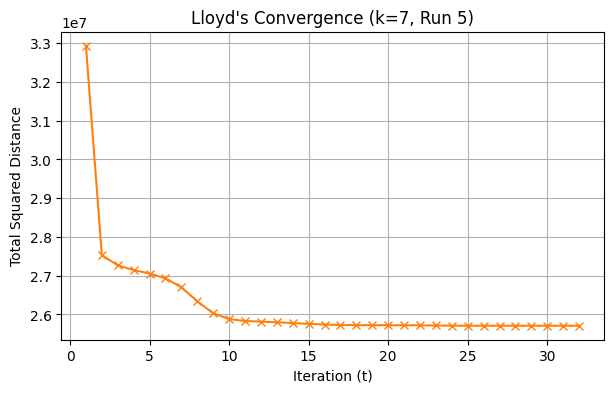

k=7 Average Results (5 runs):
 - NMI: 0.1611
 - Iterations: 26.4
 - Runtime: 5.42s
 - Distance Computations: 107,371,018


Evaluating Lloyd's Algorithm for k=30...
Converged at iteration 28
Converged at iteration 86
Converged at iteration 55
Converged at iteration 31
Converged at iteration 29


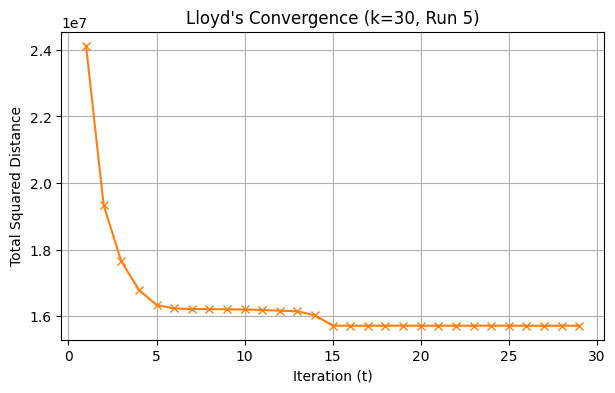

k=30 Average Results (5 runs):
 - NMI: 0.1784
 - Iterations: 45.8
 - Runtime: 15.07s
 - Distance Computations: 798,310,488


Final Report:
k=7: NMI=0.1611, Avg Iterations=26.4, Avg Runtime=5.42s, Avg Distance Computations=107,371,018
k=30: NMI=0.1784, Avg Iterations=45.8, Avg Runtime=15.07s, Avg Distance Computations=798,310,488


In [12]:
X, y = load_covertype()
result = run_experiment(X, y)
print("\nFinal Report:")
for k, metrics in result.items():
    print(f"k={k}: NMI={metrics['nmi']:.4f}, Avg Iterations={metrics['iters']:.1f}, Avg Runtime={metrics['runtime']:.2f}s, Avg Distance Computations={metrics['dist_comps']:,.0f}")

## 2. k-Means with Locality Sensitive Hashing (LSH)

Implement Lloyd’s algorithm using LSH to speed up the distance calculations. See the uploaded presentation
on Moodle on how LSH should be used.
Try out different settings in which you combine different hash functions with AND and
OR as it was discussed in the lecture. For example, you can have one setting where
you combine two hash functions with AND and in the second setting you combine two
functions with OR, but you could try out several combinations, with different hash
functions. Also try varying the number of buckets of your hashing function. Measure
the runtime $$time_{LSH}$$ of your LSH implementation.

✓ Report how you selected the parameters of LSH and how you combined your functions.

✓ Report the accuracy using NMI and the runtime in seconds averaged over at least 5
runs. Also report the number of distance computations performed. If your implementation doesn't show a speed-up, discuss why this might be and also discuss whether this situation would change when working larger datasets.

✓ Track the number of iterations needed for convergence (if it converges at all) and
compare it to the other implementations.

✓ Briefly discuss your implementation of k-means with LSH.

---

* We selected the parameters of LSH and combined the functions in 2 ways. Firstly, as a sort of balance, we chose m_and=2, L_or=3, because it should prune the number of distance computations quite a lot, and it would also be strict (as we would have 2 hash functions, so it should consider as candidates only those centers that are truly close to a point). This first try gave us a NMI=0.0816, lower than even the baseline. Secondly, we tried to improve the NMI, to have it closer to the baseline. We chose m_and=1 and L_or=5. Because of the 5 independent tables, the probability of collisions increased, which lead to more distance calculations per point, and the only hash function made each bucket to become larger. As such, we saw an improvement of the NMI (an average of 0.1277). The trade off was the higher number of distance computations. This second choice gives us an idea of what LSH is capable of, but a better choice of m_and and L_or may keep the best of our 2 tries, the higher NMI and a lower number of distance computations.

* It is notable that sometimes the LSH for k = 30 does not converge at all, as we have set max_iter=100. These runs may converge at a later iteration, but it takes too long to run.

* Our LSH implementation follows the strategy on slide 10 from the *LSH-K-Means.pdf*. It pre-calculates hash values for all points and organizes them into multiple lookup tables. It uses a combination of AND logic via hash tuples and OR logic via multiple bands to identify candidate centers for each data point. During the assignment step, distances are only calculated for centers that share a hash bucket with the point, while a fallback search handles those that do not collide. This approach reduces the total number of distance computations by pruning the search space based on random projections.

In [13]:
class LSHManager:
    def __init__(self, d, m_and, L_or, w):
        self.m_and = m_and
        self.L_or = L_or
        self.w = w
        self.a = np.random.normal(0, 1, (L_or, m_and, d))
        self.b = np.random.uniform(0, w, (L_or, m_and))

    def hash_points(self, X):
        projections = np.tensordot(self.a, X, axes=([2], [1])) + self.b[:, :, np.newaxis]
        hash_vals = np.floor(projections / self.w).astype(int)
        
        N = X.shape[0]
        hashed_data = []
        for l in range(self.L_or):
            # create a list of tuples for this specific table (band)
            table_hashes = [tuple(hash_vals[l, :, i]) for i in range(N)]
            hashed_data.append(table_hashes)
        return hashed_data

In [14]:
def build_point_lookup(point_hashes, L_or):
    # lookup[table_index][hash_tuple] = [list of point indices]
    lookup = [defaultdict(list) for _ in range(L_or)]
    for l in range(L_or):
        for idx, h_tuple in enumerate(point_hashes[l]):
            lookup[l][h_tuple].append(idx)
    return lookup

In [15]:
def assign_clusters_lsh_fast(X, mu, point_lookup, lsh_manager):
    N, k = X.shape[0], mu.shape[0]
    L = lsh_manager.L_or
    
    # initialize with infinity distance
    z = np.zeros(N, dtype=int)
    min_dists = np.full(N, np.inf)
    touched_by_lsh = np.zeros(N, dtype=bool)
    dist_comps = 0

    # hash the centers
    center_hashes = lsh_manager.hash_points(mu)

    # iterate through centers - slide 10: "Assign all points in this bucket to the center"
    for j in range(k):
        # a center has L different hash tuples (one per table)
        for l in range(L):
            c_h_val = center_hashes[l][j]
            # find points that fell into the same bucket as center j in table l
            colliding_point_indices = point_lookup[l].get(c_h_val, [])
            
            if colliding_point_indices:
                # calculate distance for these specific points only
                pts = X[colliding_point_indices]
                dists = np.sum((pts - mu[j])**2, axis=1)
                dist_comps += len(colliding_point_indices)
                
                # update assignments if this center is closer than previous candidates
                for idx_in_subset, original_idx in enumerate(colliding_point_indices):
                    if dists[idx_in_subset] < min_dists[original_idx]:
                        min_dists[original_idx] = dists[idx_in_subset]
                        z[original_idx] = j
                    touched_by_lsh[original_idx] = True

    # compute full distances for remaining points
    remaining_indices = np.where(~touched_by_lsh)[0]
    if len(remaining_indices) > 0:
        rem_X = X[remaining_indices]
        for i_idx, original_idx in enumerate(remaining_indices):
            dists = np.sum((rem_X[i_idx] - mu)**2, axis=1)
            best_j = np.argmin(dists)
            z[original_idx] = best_j
            min_dists[original_idx] = dists[best_j]
            dist_comps += k

    return z, np.sum(min_dists), dist_comps

In [16]:
def lsh_algorithm(X, k, y_true, m_and=2, L_or=3, w=4.0, max_iter=100):
    lsh_manager = LSHManager(X.shape[1], m_and, L_or, w)
    
    # pre-hash points once
    point_hashes = lsh_manager.hash_points(X)
    point_lookup = build_point_lookup(point_hashes, L_or)
    
    mu = X[:k].copy()
    z = np.zeros(X.shape[0], dtype=int)
    history = []
    total_dist_comps = 0
    start_time = time.time()

    for t in range(1, max_iter + 1):
        new_z, sq_dist, comps = assign_clusters_lsh_fast(X, mu, point_lookup, lsh_manager)
        
        total_dist_comps += comps
        history.append(sq_dist)
        
        if np.array_equal(new_z, z):
            print(f"LSH Converged at t={t}")
            break
        z = new_z.copy()
        
        for j in range(k):
            mask = (z == j)
            if np.any(mask):
                mu[j] = np.mean(X[mask], axis=0)
                
    runtime = time.time() - start_time
    nmi = normalized_mutual_info_score(y_true, z, average_method='arithmetic')
    return nmi, t, history, runtime, total_dist_comps

In [17]:
def run_experiment_lsh(X_raw, y_raw, k_values=[7, 30], num_runs=5, output_file="clustering_results.txt", m_and=2, L_or=3, w=4.0):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    with open(output_file, "a") as f:
        f.write("\n" + "="*60 + "\n")
        f.write(f"NEW EXPERIMENT RUN: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("Method: k-Means with LSH (Locality Sensitive Hashing)\n")
        f.write("Parameters: m_and=2, L_or=3, w=4.0\n")
        f.write("="*60 + "\n")

        for k in k_values:
            results_nmi = []
            results_iters = []
            results_dist = []
            results_time = []
            
            print(f"\n--- Running LSH k-Means for k={k} ---")
            
            for r in range(num_runs):
                # shuffle data so first k points vary between runs for averaging
                X_s, y_s = shuffle(X_scaled, y, random_state=r)
                
                nmi, t, history, runtime, dist_comps = lsh_algorithm(
                    X_s, k, y_s, m_and=m_and, L_or=L_or, w=w
                )
                
                results_nmi.append(nmi)
                results_iters.append(t)
                results_dist.append(dist_comps)
                results_time.append(runtime)
                print(f"Run {r+1}: NMI={nmi:.4f}, Iters={t}, Distances={dist_comps:,.0f}, Time={runtime:.2f}s")

            report_str = (f"k={k} Average Results ({num_runs} runs):\n"
                        f" - NMI: {np.mean(results_nmi):.4f}\n"
                        f" - Iterations: {np.mean(results_iters):.1f}\n"
                        f" - Distance Computations: {np.mean(results_dist):,.0f}\n"
                        f" - Runtime: {np.mean(results_time):.2f}s\n")
            print(report_str)
            f.write(report_str + "-"*30 + "\n")

X, y = load_covertype(r"datasets\covtype.data.gz")
run_experiment_lsh(X, y)

Loading Covertype dataset
Dataset Loaded Successfully.
Instances: 581012, Features: 54, Classes: 7

--- Running LSH k-Means for k=7 ---
LSH Converged at t=37
Run 1: NMI=0.1221, Iters=37, Distances=88,210,640, Time=134.79s
LSH Converged at t=43
Run 2: NMI=0.0711, Iters=43, Distances=85,570,066, Time=128.49s
LSH Converged at t=42
Run 3: NMI=0.0941, Iters=42, Distances=94,774,827, Time=131.89s
LSH Converged at t=42
Run 4: NMI=0.0657, Iters=42, Distances=99,534,424, Time=148.34s
LSH Converged at t=64
Run 5: NMI=0.0551, Iters=64, Distances=119,510,569, Time=175.16s
k=7 Average Results (5 runs):
 - NMI: 0.0816
 - Iterations: 45.6
 - Distance Computations: 97,520,105
 - Runtime: 143.74s


--- Running LSH k-Means for k=30 ---
Run 1: NMI=0.0980, Iters=100, Distances=380,398,655, Time=359.72s
LSH Converged at t=77
Run 2: NMI=0.1076, Iters=77, Distances=305,339,864, Time=290.16s
LSH Converged at t=62
Run 3: NMI=0.0965, Iters=62, Distances=256,388,301, Time=232.12s
LSH Converged at t=67
Run 4: NMI

In [25]:
X, y = load_covertype(r"datasets\covtype.data.gz")
run_experiment_lsh(X, y, m_and=1, L_or=5, w=4.0)

Loading Covertype dataset
Dataset Loaded Successfully.
Instances: 581012, Features: 54, Classes: 7

--- Running LSH k-Means for k=7 ---
Run 1: NMI=0.1454, Iters=100, Distances=462,476,109, Time=444.42s
LSH Converged at t=41
Run 2: NMI=0.1296, Iters=41, Distances=224,902,465, Time=204.17s
LSH Converged at t=35
Run 3: NMI=0.1348, Iters=35, Distances=152,659,764, Time=150.04s
LSH Converged at t=47
Run 4: NMI=0.1050, Iters=47, Distances=204,076,841, Time=188.64s
LSH Converged at t=52
Run 5: NMI=0.1237, Iters=52, Distances=306,029,428, Time=293.02s
k=7 Average Results (5 runs):
 - NMI: 0.1277
 - Iterations: 55.0
 - Distance Computations: 270,028,921
 - Runtime: 256.06s


--- Running LSH k-Means for k=30 ---
LSH Converged at t=62
Run 1: NMI=0.1649, Iters=62, Distances=959,177,173, Time=845.80s


KeyboardInterrupt: 

## 3. k-means with coresets

Coresets are a compact representation of data sets,
such that models trained on a coreset are competitive with models trained on the full
dataset [3, 1]. In this task you will implement coresets for k-means clustering as in [1,
Algorithm 1]. For the the number of samples m, use 100, 1000, and 10000.

✓ Report the runtime and NMI you achieve when using coresets of different size (as
described above) averaged over at least 5 runs. To do so, cluster the coresets using
sklearn’s k-means algorithm (you can supply sample weights to all needed functions).

✓ Track the number of iterations needed for convergence and compare it to the other
implementations.

✓ Analyze the variance of the accuracy obtained when using coresets for clustering by
computing 10 coresets for each choice of m.

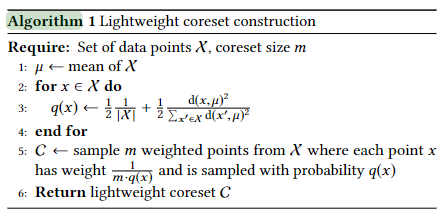

In [18]:
def construct_lightweight_coreset(X, m):
    """
    Implementation of Algorithm 1 from Bachem et al. (2018).
    X: Scaled data (N, D)
    m: Coreset size
    """
    n_samples = X.shape[0]
    
    # compute global mean mu
    mu = np.mean(X, axis=0)
    
    # compute squared distances to mean: d(x, mu)^2
    dists_sq = np.sum((X - mu)**2, axis=1)
    sum_dists_sq = np.sum(dists_sq)
    
    # proposal distribution q(x)
    q = 0.5 * (1.0 / n_samples) + 0.5 * (dists_sq / sum_dists_sq)
    
    indices = np.random.choice(n_samples, size=m, p=q, replace=True)
    X_coreset = X[indices]
    
    weights = 1.0 / (m * q[indices])
    
    return X_coreset, weights

In [23]:
def run_coreset_task(X_raw, y_raw, k_values=[7, 30], m_values=[100, 1000, 10000], output_file="clustering_results.txt"):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    final_results = {}

    with open(output_file, "a") as f:
        f.write("\n" + "="*60 + "\n")
        f.write(f"NEW EXPERIMENT RUN: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("Method: k-Means with Lightweight Coresets\n")
        f.write("Note: Accuracy averaged over 10 coresets per size m\n")
        f.write("="*60 + "\n")

        for k in k_values:
            print(f"\n{'='*40}\nEvaluating for k={k}\n{'='*40}")
            for m in m_values:
                nmis = []
                iters = []
                runtimes = []
                
                for i in range(10):
                    start_time = time.time()
                    
                    X_coreset, weights = construct_lightweight_coreset(X_scaled, m)
                    
                    kmeans = KMeans(n_clusters=k, init='random', n_init=1, max_iter=300)
                    kmeans.fit(X_coreset, sample_weight=weights)
                    
                    # predict on full dataset to compute NMI
                    full_assignments = kmeans.predict(X_scaled)
                    
                    end_time = time.time()
                    
                    nmi = normalized_mutual_info_score(y_raw, full_assignments, average_method='arithmetic')
                    
                    nmis.append(nmi)
                    iters.append(kmeans.n_iter_)
                    runtimes.append(end_time - start_time)
                
                report_str = (f"k={k}, Coreset size m={m} Average Results (10 runs):\n"
                            f" - NMI: {np.mean(nmis):.4f} (Std: {np.std(nmis):.4f})\n"
                            f" - Iterations: {np.mean(iters):.1f}\n"
                            f" - Runtime: {np.mean(runtimes):.4f}s\n")
                print(report_str)
                f.write(report_str + "-"*30 + "\n")
                
                final_results[(k, m)] = nmis

    return final_results

X, y = load_covertype()
results = run_coreset_task(X, y)

Loading Covertype dataset
Dataset Loaded Successfully.
Instances: 581012, Features: 54, Classes: 7

Evaluating for k=7
k=7, Coreset size m=100 Average Results (10 runs):
 - NMI: 0.1214 (Std: 0.0337)
 - Iterations: 6.5
 - Runtime: 0.2537s

k=7, Coreset size m=1000 Average Results (10 runs):
 - NMI: 0.1555 (Std: 0.0338)
 - Iterations: 15.7
 - Runtime: 0.2665s

k=7, Coreset size m=10000 Average Results (10 runs):
 - NMI: 0.1735 (Std: 0.0357)
 - Iterations: 13.9
 - Runtime: 0.2665s


Evaluating for k=30
k=30, Coreset size m=100 Average Results (10 runs):
 - NMI: 0.1554 (Std: 0.0090)
 - Iterations: 4.9
 - Runtime: 0.2620s

k=30, Coreset size m=1000 Average Results (10 runs):
 - NMI: 0.1757 (Std: 0.0071)
 - Iterations: 11.5
 - Runtime: 0.2591s

k=30, Coreset size m=10000 Average Results (10 runs):
 - NMI: 0.1803 (Std: 0.0065)
 - Iterations: 15.5
 - Runtime: 0.2874s



-----
**Note:** By definition, variance is the square of the standard deviation. Because we already have a small standard deviation, the variance would be even smaller, really close to 0. So we chose to print the standard deviation instead of variance, to see it better on a computer.

**Second note:** The NMI is computed for the all dataset, not just the coreset selected.

A small standard deviance (all of them are smaller than 0.04, which represent at maximum a variance of 0.0016) means that the algorithm with coresets is producing consistent results, so it chooses a representative summary of the full dataset each time.

-----

## Report

Write a report about your work on this assignment, your findings and results. Make
sure to report all the information indicated above. Additionally report the following:

✓ Show the performance in terms of NMI and runtime for the different approaches in
one plot or table.

-----

| Method | NMI | Runtime | Iterations | Dist. Computations |
| :--- | :---: | :---: | :---: | :---: |
| Lloyd's (Baseline, k=7) | 0.1611 | 5.42s | 26.4 | 107,371,018 |
| Lloyd's (Baseline, k=30) | 0.1784 | 15.07s | 45.8 | 798,310,488 |
| LSH (m=2, L=3, k=7) | 0.0816 | 143.74s | 45.6 | 97,520,105 |
| LSH (m=1, L=5, k=7) | 0.1277 | 256.06s | 55.0 | 270,028,921 |
| LSH (m=2, L=3, k=30) | 0.0996 | 299.11s | 81.2 | 327,247,712 |
| Coresets (m=100, k=7) | 0.1127 | 0.2380s | 6.9 | - |
| Coresets (m=1000, k=7) | 0.1444 | 0.2304s | 11.3 | - |
| Coresets (m=10000, k=7) | 0.1514 | 0.2793s | 14.1 | - |
| Coresets (m=100, k=30) | 0.1600 | 0.2857s | 5.1 | - |
| Coresets (m=1000, k=30) | 0.1827 | 0.3121s | 13.3 | - |
| Coresets (m=10000, k=30) | 0.1828 | 0.3126s | 16.3 | - |

We can observe that the number of iterations differ greatly between the 3 main methods. The baseline has 26 iterations for 7 clusters and 46 iterations for 30 clusters, which is manageable, considering that it has a high NMI and the runtime is quite good.

Then, the LSH is the one that has the longest runtime, and requires the most iterations. Although in each iteration it does fewer distance computations, it needs more iterations to converge, which it makes it more unstable.

Lastly, the coresets are the best on this dataset. They require few iterations, are the fastest and have a high NMI. This behaviour is expected, as seen in the paper *"Scalable k-Means Clustering via Lightweight Coresets"*, as they usually are a very good representation of the larger dataset. 